Bu jupyter notebook dosyasını indirip Amazon.com satılan elektronik ürünleri için yazılan 1 milyon 689 bin 188 yorum hakkında öğrendiğimiz bütün NLP metodları uygulayıp, küçük harfe çevirip, noktalama işaretlerini ve HTML taglerini kaldırıp, 'stopwords'leri kaldırıp iyi ve kötü yorumlar hakkında wordcloud (Kelime bulutu) oluşturup, Overall Sütunundaki rating'e göre classification algoritmalarını çalıştırarak, yeni gelecek yorumların rating'ini tahmin eden bir model geliştirp, NER(Named Entity Recognition) gibi konuları araştırip bir sonuca varacagiz.

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
# Toplam kaç kayıt var görelim
# print("Toplam yorum sayısı:", len(df))

# Rastgele 400.000 sample al
# df_sample = df.sample(n=400_000, random_state=42)

# Due to computational constraints, a stratified subset of 400,000 reviews was constructed from the original dataset.

In [3]:
#output_path = "/content/drive/MyDrive/amazon_reviews_400k.csv"

#df_sample.to_csv(output_path, index=False)

# print("Dosya Drive'a kaydedildi:", output_path)


In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [5]:
df=pd.read_csv('/content/drive/MyDrive/NLP Project-Colab Only/amazon_reviews_400k.csv')

In [6]:
df.shape

(400000, 9)

Buraya kadar dosyanin url uzantili olarak webden erisim saglanmasi ve akabinde dosyadan 400000 sample alinmasi ile bir csv dosyasi olusturduk. Boylece ana 1.2 gb boyutundaki ana dosyadan kurtulmus olduk.

In [7]:
df.head()

,reviewerID,asin,reviewerName,helpful,reviewText,overall,summary,unixReviewTime,reviewTime
0,A3E3VF85DAW0FU,B004M8S12A,RedRover,"[57, 67]","Well, after trying out some Box Towers....that...",5,Best in Class,1307404800,"06 7, 2011"
1,A15X0XCY1EKJHL,B002KANXBG,"James Stitley ""Jim Stitley""","[16, 16]",I ordered one for my wife and one for me. Afte...,5,S 70 Review,1261612800,"12 24, 2009"
2,A393R1LK2A468F,B0050I1PHO,nelson 8A,"[3, 7]",muy buen producto... a full en juegos fHD.... ...,5,nice,1314576000,"08 29, 2011"
3,AEL8SXIP0GNYU,B000JNA4LS,Scott,"[0, 0]",The sound quality of this unit is phenomenal. ...,5,Crushes Bose SoundDock II,1235433600,"02 24, 2009"
4,A3O2Z9D0Y0G5XQ,B009VV56TY,Reese,"[0, 0]",It is good on keeping your cpu cool also down'...,4,it does what it say.,1401148800,"05 27, 2014"


Only the `overall` and the `unixReviewTime` series are stored as integers. The rest are interpreted as strings (objects).

In [8]:
!ls -al

total 20
drwxr-xr-x 1 root root 4096 Jun  4 09:44 .
drwxr-xr-x 1 root root 4096 Jun  4 09:35 ..
drwxr-xr-x 4 root root 4096 May 26 13:31 .config
drwx------ 5 root root 4096 Jun  4 09:44 drive
drwxr-xr-x 1 root root 4096 May 26 13:31 sample_data


In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 400000 entries, 0 to 399999
Data columns (total 9 columns):
 #   Column          Non-Null Count   Dtype 
---  ------          --------------   ----- 
 0   reviewerID      400000 non-null  object
 1   asin            400000 non-null  object
 2   reviewerName    394003 non-null  object
 3   helpful         400000 non-null  object
 4   reviewText      399758 non-null  object
 5   overall         400000 non-null  int64 
 6   summary         399997 non-null  object
 7   unixReviewTime  400000 non-null  int64 
 8   reviewTime      400000 non-null  object
dtypes: int64(2), object(7)
memory usage: 27.5+ MB


In [10]:
# verimiz cok, bos verileri atarak temiz degerler elde ederiz.
# df.dropna(axis=0, inplace=True)
# yukaridaki kismi 01.06.2026 tarihinde degistirdik.
# artik asagidaki kisim gunceldir.


# Sadece reviewText'i bos olanlari at; reviewerName null'lari (gecerli yorumlar) KORUNUR
# Drop only rows with empty reviewText; keep valid reviews that merely lack reviewerName
before = len(df)
df.dropna(subset=["reviewText"], inplace=True)
print(f"Silinen / dropped: {before - len(df)} | Kalan / remaining: {len(df)}")

Silinen / dropped: 242 | Kalan / remaining: 399758


##### Asagida tarih iceren sutunda tarihsel bilgiyi tasiyacak sekilde donusum yapmamiz gereklidir, aksi durumda tarih sutunu kullanilamaz.

In [11]:
from datetime import datetime

condition = lambda row: datetime.fromtimestamp(row).strftime("%m-%d-%Y")
df["unixReviewTime"] = df["unixReviewTime"].apply(condition)

The `reviewTime` is dropped since the `unixReviewTime` series more accurately describes the time when each review was posted.

In [12]:
df.drop(labels="reviewTime", axis=1, inplace=True)

In [13]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 399758 entries, 0 to 399999
Data columns (total 8 columns):
 #   Column          Non-Null Count   Dtype 
---  ------          --------------   ----- 
 0   reviewerID      399758 non-null  object
 1   asin            399758 non-null  object
 2   reviewerName    393761 non-null  object
 3   helpful         399758 non-null  object
 4   reviewText      399758 non-null  object
 5   overall         399758 non-null  int64 
 6   summary         399755 non-null  object
 7   unixReviewTime  399758 non-null  object
dtypes: int64(1), object(7)
memory usage: 27.4+ MB


Each review is stored as string in the `reviewText` series. A sample product review is below:

In [14]:
print(df["reviewText"].iloc[0])

Well, after trying out some Box Towers....that sounded like music in a box......I tried Magnepan MMGs. They HAVE to be the best in their class....about $600 the pair.....but typical planars....small imaging.....4 ohm power hungry.....sound slightly strained.....4 or 5 Feet out from the wall.....but still....I wanted more.I bought a set of ElectroMotion ESLs from Amazon. I power them with a 35 YO Receiver, the NAD 7175. It is so good, it is scary accurate.If you buy a Small stereo system, it sounds like you have a small sound coming out of a small box......If you buy Better tower Speakers.....it might sound like you are setting at a concert on the 50th row of a 100 row theater.If you buy some very, very good box speakers.....it might move you down to the first rows......And it might not.But if you buy really well made and balanced ElectroStatics, like these MartinLogans....the artists are in your living room.You can hear them breathing.......Some say the Bass is thin. Don't believe them

Each review is associated with a rating stored under the `overall` field. This serves as the quantified summary of a given review and will thus be used as the ground truth labels for the model.

In [15]:
df.head()

,reviewerID,asin,reviewerName,helpful,reviewText,overall,summary,unixReviewTime
0,A3E3VF85DAW0FU,B004M8S12A,RedRover,"[57, 67]","Well, after trying out some Box Towers....that...",5,Best in Class,06-07-2011
1,A15X0XCY1EKJHL,B002KANXBG,"James Stitley ""Jim Stitley""","[16, 16]",I ordered one for my wife and one for me. Afte...,5,S 70 Review,12-24-2009
2,A393R1LK2A468F,B0050I1PHO,nelson 8A,"[3, 7]",muy buen producto... a full en juegos fHD.... ...,5,nice,08-29-2011
3,AEL8SXIP0GNYU,B000JNA4LS,Scott,"[0, 0]",The sound quality of this unit is phenomenal. ...,5,Crushes Bose SoundDock II,02-24-2009
4,A3O2Z9D0Y0G5XQ,B009VV56TY,Reese,"[0, 0]",It is good on keeping your cpu cool also down'...,4,it does what it say.,05-27-2014


## NLP Pre-Processing ##
We'll work with `reviewText` to prepare our model's final dataframe. The goal is to produce tokens for every document (i.e. every review). These documents will make up our corpora where we'll draw our vocabulary from.

The following is a sample text in its original form.

#### Modelleme DataFrame kullanimi

In [16]:
df_model = df[["reviewText", "overall"]].copy()

In [17]:
# df_model["text_plus"] = df["summary"] + " " + df["reviewText"]



# This will be extra

#### Analiz icin dataframe kullanimi

In [18]:
# 01.06.2026 tarihinde asagidaki kodun sonuna .copy() ekledik.

df_analysis = df[["overall", "unixReviewTime", "summary", "reviewText"]].copy()

Bu asamada reviewTextlerin hepsini temizliyoruz ki duzgun ve modele sokulacak anlamli kelimeler elde edebilelim.

In [19]:
df_model["reviewText"] = (
    df_model["reviewText"]
    .str.lower()
    .str.replace(r"[\n\r]", " ", regex=True)   # satır sonları
    .str.replace(r"<.*?>", "", regex=True)     # HTML
    .str.replace(r"[^\w\s]", "", regex=True)   # punctuation
    .str.replace(r"\d+", "", regex=True)       # digits
    .str.replace(r"\s+", " ", regex=True)      # extra spaces
    .str.strip()
)

In [20]:
df_model['reviewText'].head()

,reviewText
0,well after trying out some box towersthat soun...
1,i ordered one for my wife and one for me after...
2,muy buen producto a full en juegos fhd no hay ...
3,the sound quality of this unit is phenomenal w...
4,it is good on keeping your cpu cool also downt...


### Veri Kalitesi: Çok Dilli İçerik
Veri setinde az sayıda (~%0.1, 400k'da ~501 yorum) İngilizce dışı (çoğunlukla İspanyolca/
Portekizce) yorum bulunmaktadır. Bu yorumlar TF-IDF vocabulary'sine sessiz gürültü olarak
girer. Oran çok düşük olduğu için filtrelenmemiş, ancak modelin küçük bir hata kaynağı olarak
not edilmiştir.


In [21]:
# Veri kalitesi notu: cok dilli (non-English) yorum tespiti (mention amacli, filtrelemiyoruz)
# Heuristic: yeterince uzun AMA hic yaygin Ingilizce stopword icermeyen yorum -> muhtemelen non-English
ENGLISH_COMMON = r"\b(the|and|is|it|this|to|of|a|in|for|with|that|was|but|you|have|on|are|my|not)\b"
_low = df_model["reviewText"].str.lower()
_likely_non_en = (_low.str.split().str.len() >= 5) & (_low.str.count(ENGLISH_COMMON) == 0)
print(f"Muhtemelen Ingilizce-disi yorum: {_likely_non_en.sum()} (%{100*_likely_non_en.mean():.2f})")
df_model[_likely_non_en]["reviewText"].head(8)


Muhtemelen Ingilizce-disi yorum: 501 (%0.13)


,reviewText
1310,funciona muy bien me gusta que se ilumuna cuan...
1796,excelente fan cooler silencioso tremendo flujo...
2008,es pequentildea y muy funcional la puedes enga...
2479,vw jetta works grate im very happy
3359,i would say an obvious choice when replacing y...
3563,el estuche es super uacutetil y exacto para mi...
4609,desde que marqueacute el producto supe que har...
5876,fits canon oem lenses perfectly


### **Labeling and Coding**

Since we tried a model with 5 class in overall column and couldnt able to make a good prediction model, we need to decrease labels to make our model more accurate.

In [22]:
def label_overall(overall):
    if overall <= 2:
        return 0   # negative text
    elif overall == 3:
        return 1   # neutral text
    else:
        return 2   # positive text
df_model['sentiment'] = df_model['overall'].apply(label_overall)

In [23]:
df_model['sentiment'].value_counts()

,count
sentiment,
2,321082
0,45295
1,33381


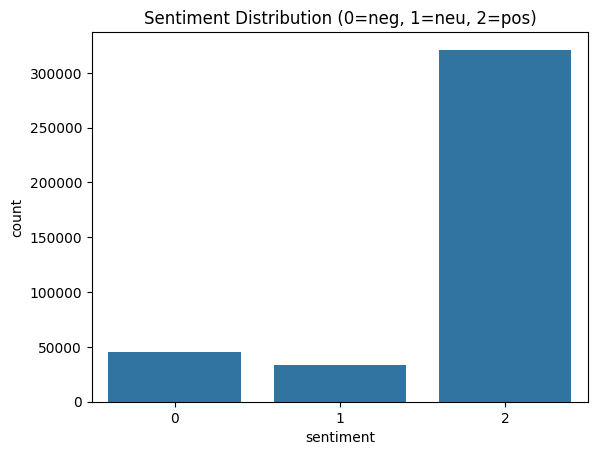

In [24]:
sns.countplot(x=df_model["sentiment"])
plt.title("Sentiment Distribution (0=neg, 1=neu, 2=pos)")
plt.show()

In [25]:
df_analysis['sentiment'] = df_analysis['overall'].apply(label_overall)

In [26]:
df_model.head()

,reviewText,overall,sentiment
0,well after trying out some box towersthat soun...,5,2
1,i ordered one for my wife and one for me after...,5,2
2,muy buen producto a full en juegos fhd no hay ...,5,2
3,the sound quality of this unit is phenomenal w...,5,2
4,it is good on keeping your cpu cool also downt...,4,2


### TrainTestSplit

In [27]:
from sklearn.model_selection import train_test_split

x = df_model["reviewText"]
y = df_model["sentiment"]

x_train, x_test, y_train, y_test = train_test_split(
    x, y, test_size=0.2, random_state=42, stratify=y
)

### TfidfVectorizer

In [28]:
from sklearn.feature_extraction.text import TfidfVectorizer

In [29]:
tfidf = TfidfVectorizer(
    lowercase=True,                 # case normalize
    strip_accents="unicode",        # accent removal (hızlı, C-level)
    ngram_range=(1, 2),             # unigram + bigram (sweet spot)
    min_df=2,                       # çok nadir kelimeleri at
    max_df=0.95,                    # aşırı sık (stopword benzeri) kelimeleri at
    max_features=300_000,           # RAM & feature explosion kontrolü
    sublinear_tf=True,              # log(1+tf) -> stabil ağırlıklar
    norm="l2",                      # linear modeller için ideal
    # dtype="float32"                 # RAM'i ~%50 düşürür
)

TF-IDF vectorization with unigram and bigram features was employed, as it effectively captures local word co-occurrences without requiring explicit phrase modeling or linguistic normalization, while maintaining computational efficiency for large-scale text data.

### Modelling

In [30]:
from sklearn.linear_model import SGDClassifier, LogisticRegression
from sklearn.svm import LinearSVC

# asagidaki importlari 01.06.2026 da ilave ettim.

from sklearn.base import clone
from sklearn.model_selection import cross_val_score, StratifiedKFold

models = {
    "SGD": SGDClassifier(loss="hinge", class_weight="balanced", random_state=42),
    "Logistic": LogisticRegression(
        max_iter=1000,
        n_jobs=-1,
        class_weight="balanced"
    ),
    "LinearSVC": LinearSVC(class_weight="balanced")
}


### Training- Model Evalueting

In [31]:
from sklearn.pipeline import Pipeline
from sklearn.metrics import f1_score, classification_report, accuracy_score, confusion_matrix
import time

In [32]:
cv = StratifiedKFold(n_splits=2, shuffle=True, random_state=42)
results = {}

for name, model in models.items():
    print(f"\n===== {name} =====")
    # FIX (Bug 2): clone(tfidf) -> her pipeline bagimsiz/tertemiz vectorizer alir
    pipe = Pipeline([("tfidf", clone(tfidf)), ("model", model)])

    start = time.perf_counter()
    # FIX (Problem 2): cross-validation (sadece train uzerinde -> leakage yok)
    cv_f1 = cross_val_score(pipe, x_train, y_train, cv=cv, scoring="f1_macro", n_jobs=-1)

    pipe.fit(x_train, y_train)
    y_pred = pipe.predict(x_test)
    elapsed = time.perf_counter() - start

    report = classification_report(y_test, y_pred, output_dict=True)
    report["cv_macro_f1_mean"] = cv_f1.mean()
    report["cv_macro_f1_std"] = cv_f1.std()
    results[name] = report

    print(classification_report(y_test, y_pred))
    print(f"CV macro-F1: {cv_f1.mean():.4f} ± {cv_f1.std():.4f}")
    print(f"⏱️ Süre: {elapsed:.1f}s")




===== SGD =====
              precision    recall  f1-score   support

           0       0.66      0.70      0.68      9059
           1       0.53      0.08      0.13      6676
           2       0.90      0.97      0.93     64217

    accuracy                           0.86     79952
   macro avg       0.69      0.58      0.58     79952
weighted avg       0.84      0.86      0.84     79952

CV macro-F1: 0.5857 ± 0.0012
⏱️ Süre: 251.2s

===== Logistic =====
              precision    recall  f1-score   support

           0       0.63      0.76      0.69      9059
           1       0.30      0.53      0.38      6676
           2       0.96      0.86      0.91     64217

    accuracy                           0.82     79952
   macro avg       0.63      0.72      0.66     79952
weighted avg       0.87      0.82      0.84     79952

CV macro-F1: 0.6520 ± 0.0002
⏱️ Süre: 460.0s

===== LinearSVC =====
              precision    recall  f1-score   support

           0       0.68      0.

Bu modelde gerek basarili bir model yakalamak, gerek de RAM i cokturup basarisiz olmamasi icin en iyi Linear modeller yakalanmistir, NaiveBayes modeli ile basari orani cok dusuk ciktigi icin modelden cikarilmis ve 3 modele indirgenmistir.

#### Model Comparison- Macro F1

In [33]:
summary = []
for model_name, metrics in results.items():
    summary.append({
        "Model": model_name,
        "CV Macro F1": metrics["cv_macro_f1_mean"],
        "Test Macro F1": metrics["macro avg"]["f1-score"],
        "Accuracy": metrics["accuracy"],
    })
summary_df = pd.DataFrame(summary).sort_values("CV Macro F1", ascending=False).reset_index(drop=True)
summary_df


,Model,CV Macro F1,Test Macro F1,Accuracy
0,Logistic,0.652022,0.661569,0.821293
1,LinearSVC,0.646879,0.658665,0.863756
2,SGD,0.585681,0.581259,0.864456


### Confusion Matrix for Best Model

###### Logistic model

Secilen model / chosen: Logistic


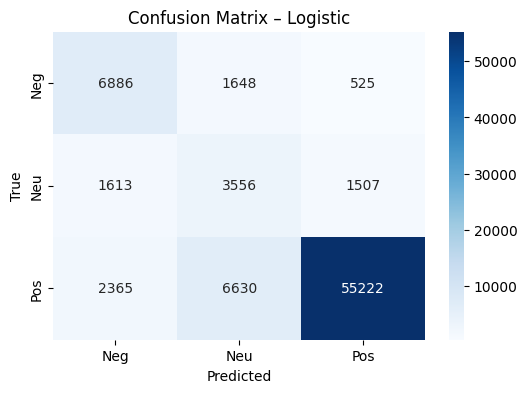

In [34]:
# FIX (Bug 3): kirilgan iloc[1] yerine acik/reproducible secim
# SECENEK A (onerilen): macro-F1'e gore en iyi -> Logistic
# 01.06.2026 tarihinde degistirdik bu blogun bir kismini.
best_model_name = summary_df.loc[summary_df["CV Macro F1"].idxmax(), "Model"]

# SECENEK B: accuracy+hiz oncelikliysen bilincli olarak LinearSVC sec
# best_model_name = "LinearSVC"   # gerekce: yuksek accuracy ve hizli inference

best_model = models[best_model_name]
print(f"Secilen model / chosen: {best_model_name}")

best_pipe = Pipeline([
    ("tfidf", clone(tfidf)),
    ("model", best_model)
])

best_pipe.fit(x_train, y_train)
y_pred_best = best_pipe.predict(x_test)

cm = confusion_matrix(y_test, y_pred_best)

plt.figure(figsize=(6,4))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Neg", "Neu", "Pos"],
    yticklabels=["Neg", "Neu", "Pos"]
)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title(f"Confusion Matrix – {best_model_name}")
plt.show()




### Error Analysis

In [35]:
error_df = pd.DataFrame({
    "text": x_test,
    "true": y_test,
    "pred": y_pred_best
})

errors = error_df[error_df["true"] != error_df["pred"]]
errors.sample(20, random_state=42)


,text,true,pred
63670,im pretty amazed first of all at how processor...,1,2
3856,ill preface this by mentioning that im a photo...,2,1
192617,placed is as an intake fan at the bottom of my...,2,1
27877,i was going to give it stars because i followe...,2,1
94444,what complete idiot made the decision to girly...,1,2
107120,this is not a bad unit when you order it and w...,2,0
387830,pretty good for price the flip up stands on th...,2,1
102569,i have the hdmi splitter connected between my ...,0,1
74872,fits my hand well i really like the fact the u...,2,1
90414,pretty nice but must pay extra for cloud recor...,2,1


In [36]:
errors["error_type"] = errors["true"].astype(str) + "→" + errors["pred"].astype(str)
errors["error_type"].value_counts()


/tmp/ipykernel_2271/274516591.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  errors["error_type"] = errors["true"].astype(str) + "→" + errors["pred"].astype(str)


,count
error_type,
2→1,6630
2→0,2365
0→1,1648
1→0,1613
1→2,1507
0→2,525


Burada birbirine yakin kelimelerin ic ice gecmesi ile ozellikle notr pozitif ve pozitif notr arasinda modelin tam da tahmin edilir seviyede hata yaptigini gosteriyor. onu da notrden negatife gecis takip ediyor ki modelimiz icin oldukca olumludur. 0dan 2 ve 2 den 0 adetleri nazaran daha az seviyede kalmistir.

### Nötr Sınıf Krizi ve 2-Class Deneyi
3-class modelde nötr sınıf (3-yıldız) recall ~0.35, f1 ~0.31 ile çökmektedir.
Sebep: 3-yıldız yorumlar dil olarak pozitif/negatif arası belirsizdir (low sentiment signal).
Standart bir fallback olarak nötr sınıfı çıkarıp problemi binary (neg vs pos)
hale getirdiğimizde model çok daha güvenilir hale gelir. Karşılaştırma aşağıdadır.

              precision    recall  f1-score   support

         neg       0.66      0.90      0.76      9059
         pos       0.99      0.93      0.96     64217

    accuracy                           0.93     73276
   macro avg       0.82      0.92      0.86     73276
weighted avg       0.95      0.93      0.94     73276

2-class macro-F1: 0.8613
2-class accuracy: 0.9306


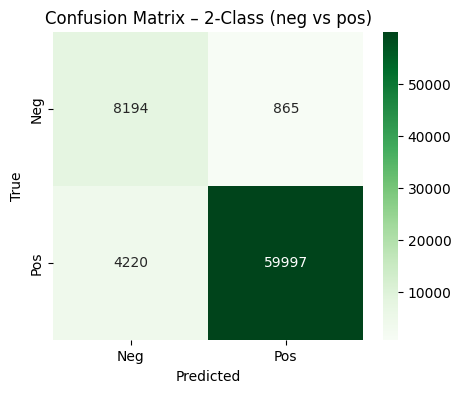

In [37]:
# burasi tamamen 01.06.2026 tarihinde gelmistir.
# ===== 2-CLASS DENEYI: notr (3-yildiz) cikar, neg vs pos =====
from sklearn.metrics import f1_score, accuracy_score

# notru (sentiment==1) cikar; pos(2)->1, neg(0)->0 binary etiket
df_bin = df_model[df_model["sentiment"] != 1].copy()
df_bin["binary"] = (df_bin["sentiment"] == 2).astype(int)

xb = df_bin["reviewText"]
yb = df_bin["binary"]
xb_train, xb_test, yb_train, yb_test = train_test_split(
    xb, yb, test_size=0.2, random_state=42, stratify=yb
)

# secilen best_model'in temiz bir kopyasi ile (clone -> ayni parametreler, fit edilmemis)
bin_pipe = Pipeline([("tfidf", clone(tfidf)), ("model", clone(best_model))])
bin_pipe.fit(xb_train, yb_train)
yb_pred = bin_pipe.predict(xb_test)

print(classification_report(yb_test, yb_pred, target_names=["neg", "pos"]))
print(f"2-class macro-F1: {f1_score(yb_test, yb_pred, average='macro'):.4f}")
print(f"2-class accuracy: {accuracy_score(yb_test, yb_pred):.4f}")

# karsilastirma (3-class degerlerini summary_df'ten hatirla)
cm_bin = confusion_matrix(yb_test, yb_pred)
plt.figure(figsize=(5,4))
sns.heatmap(cm_bin, annot=True, fmt="d", cmap="Greens",
            xticklabels=["Neg","Pos"], yticklabels=["Neg","Pos"])
plt.xlabel("Predicted"); plt.ylabel("True")
plt.title("Confusion Matrix – 2-Class (neg vs pos)")
plt.show()


### Predict Sentences

In [38]:
new_sentences=["this product is fine although it have some rough shapes we dont find it smart still it is good.",
               "I am not sure that i would want to have this again.",
               "hey, this is really fantastic.",
               "it is not good at all"]

In [39]:
predictions = best_pipe.predict(new_sentences)
predictions

array([1, 1, 2, 0])

It seems good performance above.

###**WordCloud**

In [40]:
from wordcloud import WordCloud
from wordcloud import STOPWORDS
from PIL import Image

In [41]:
def wc(data, color):
    """Generate and display a word cloud from an iterable of texts (kelime bulutu)."""
    plt.figure(figsize=(10, 10))
    cloud = WordCloud(background_color=color, stopwords=STOPWORDS)  # fonksiyon adiyla cakismaz
    cloud.generate(" ".join(data))
    plt.imshow(cloud)
    plt.axis("off")


In [42]:
positive_value=df_model[df_model['sentiment']==2]
neutral_value=df_model[df_model['sentiment']==1]
negative_value=df_model[df_model['sentiment']==0]

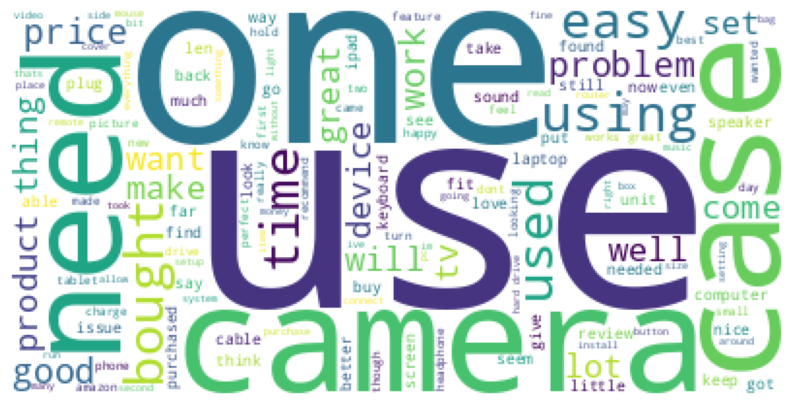

In [43]:
wc(positive_value['reviewText'],'white')

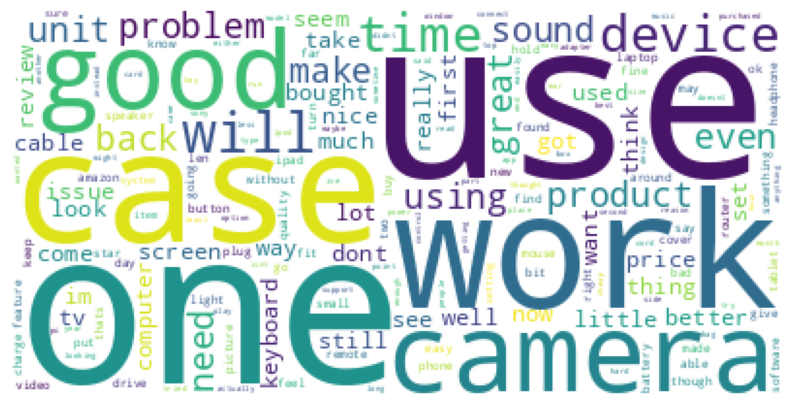

In [44]:
wc(neutral_value['reviewText'],'white')

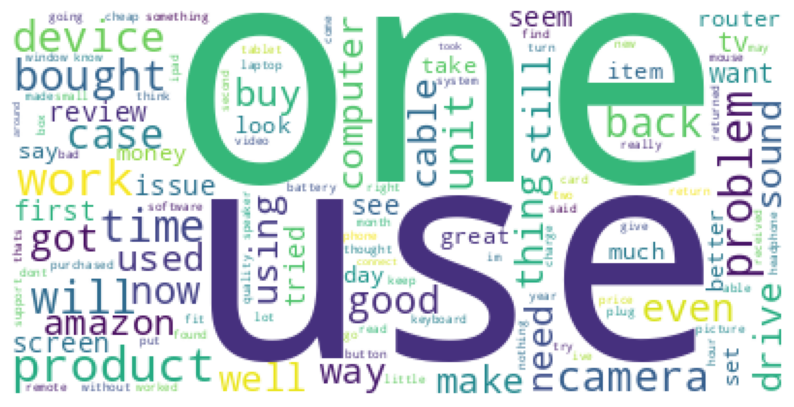

In [45]:
wc(negative_value['reviewText'],'white')

# NER Analysis

> **Not:** `en_core_web_sm` kucuk bir modeldir; NER dogrulugu sinirlidir. Bulgular bu sinir dahilinde yorumlanmalidir (daha yuksek dogruluk icin `en_core_web_trf` kullanilabilir).

In [46]:
import spacy
from collections import defaultdict
from spacy import displacy

nlp = spacy.load(
    "en_core_web_sm",
    disable=["tagger", "parser", "lemmatizer"]
)

In [47]:
error_df = pd.DataFrame({
    "text": x_test,
    "true": y_test,
    "pred": y_pred_best
})

correct_preds = error_df[error_df["true"] == error_df["pred"]] # modelin rahat ettigi metinler
error_preds   = error_df[error_df["true"] != error_df["pred"]] # modelin zorlandigi metinler

In [48]:
sample_text = error_preds.iloc[0]["text"]
doc = nlp(sample_text)

ner_dict = defaultdict(list)
for ent in doc.ents:
    ner_dict[ent.label_].append(ent.text)

for label, items in ner_dict.items():
    print(label, ":", set(items))

displacy.render(doc, style="ent", jupyter=True)
# burasi sadece ornek bir gosterim icindir.


CARDINAL : {'one'}
TIME : {'another minutes', 'an hour'}
DATE : {'another day'}


In [49]:
def count_entities_fast(texts, batch_size=1000):
    counts = []
    for doc in nlp.pipe(texts, batch_size=batch_size):
        counts.append(len(doc.ents))
    return counts
# ner analizi icin belkemigi kisimdir.

In [50]:
# NER için temsilî örnek (yeterli ve hızlı)

correct_sample = correct_preds.sample(n=10000, random_state=42)
error_sample   = error_preds.sample(n=10000, random_state=42)

correct_sample["entity_count"] = count_entities_fast(correct_sample["text"])
error_sample["entity_count"]   = count_entities_fast(error_sample["text"])


In [51]:
correct_mean = correct_sample["entity_count"].mean()
error_mean   = error_sample["entity_count"].mean()

correct_mean, error_mean


(np.float64(1.4276), np.float64(2.0035))

In [52]:
ner_summary = pd.DataFrame({
    "Group": ["Correctly Classified", "Misclassified"],
    "Avg Entity Count": [correct_mean, error_mean]
})

ner_summary


,Group,Avg Entity Count
0,Correctly Classified,1.4276
1,Misclassified,2.0035


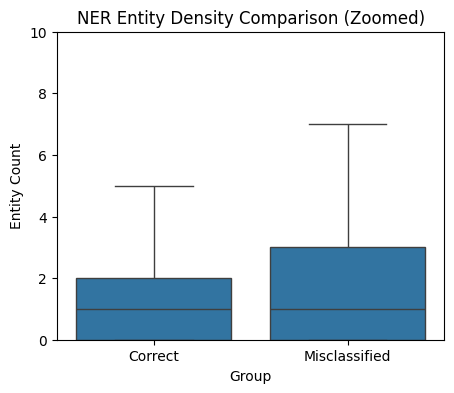

In [53]:
plot_df = pd.DataFrame({
    "Entity Count": pd.concat([
        correct_sample["entity_count"].reset_index(drop=True),
        error_sample["entity_count"].reset_index(drop=True)
    ]),
    "Group": (
        ["Correct"] * len(correct_sample) +
        ["Misclassified"] * len(error_sample)
    )
})

plt.figure(figsize=(5,4))
sns.boxplot(
    data=plot_df,
    x="Group",
    y="Entity Count",
    showfliers=False
)

plt.ylim(0,10)
plt.title("NER Entity Density Comparison (Zoomed)")
plt.show()


In [54]:
(
    (error_sample["entity_count"] > 0).mean(),
    (correct_sample["entity_count"] > 0).mean()
)


(np.float64(0.6045), np.float64(0.5347))

In [55]:
# BURAYA 01.06.2026 TARIHINDE YAPILAN GUNCELLEME GELDI.

# FIX (Problem 5): text-length confounding kontrolu
# Ham entity sayisi yaniltici olabilir: uzun metin -> hem daha cok entity
# hem daha zor siniflandirma. Cozum: entity YOGUNLUGU (entity/kelime) + istatistik testi.


from scipy.stats import mannwhitneyu

for s in (correct_sample, error_sample):
    s["word_count"] = s["text"].str.split().str.len()
    s["entity_density"] = s["entity_count"] / s["word_count"].clip(lower=1)

def _cmp(col):
    cm, em = correct_sample[col].mean(), error_sample[col].mean()
    _, p = mannwhitneyu(correct_sample[col], error_sample[col], alternative="two-sided")
    print(f"{col:16s} | correct {cm:.4f} | error {em:.4f} | oran {em/cm:.3f} | p={p:.4g}")


print("Uzunluk (kontrol degiskeni):"); _cmp("word_count")
print("Ham entity sayisi:");           _cmp("entity_count")
print("Entity YOGUNLUGU (normalize):"); _cmp("entity_density")

Uzunluk (kontrol degiskeni):
word_count       | correct 105.4814 | error 148.0517 | oran 1.404 | p=7.383e-129
Ham entity sayisi:
entity_count     | correct 1.4276 | error 2.0035 | oran 1.403 | p=8.807e-44
Entity YOGUNLUGU (normalize):
entity_density   | correct 0.0129 | error 0.0131 | oran 1.011 | p=3.324e-06


### NER Bulgusunun Confounding Kontrolü
Ham entity sayısı yanıltıcı olabilir; bu yüzden text uzunluğuna göre normalize edilmiş
entity yoğunluğu (entity/kelime) ile karşılaştırma ve Mann-Whitney U testi eklendi.

In [56]:
def ner_table_for_texts(texts, nlp, max_texts=100):
    ner_dict = defaultdict(set)

    for doc in nlp.pipe(texts[:max_texts]):
        for ent in doc.ents:
            ner_dict[ent.label_].add(ent.text)

    ner_df = pd.DataFrame([
        {
            "Entity Type": label,
            "Unique Entity Count": len(values),
            "Sample Entities": ", ".join(list(values)[:10])
        }
        for label, values in ner_dict.items()
    ]).sort_values("Unique Entity Count", ascending=False)

    return ner_df


#### Modelin zorlandigi yorumlar alindi ve bunlar icindeki bilgi odakli entity typelar tek tek cikarildi asagida.
#### Yanlis yorumlanan yorumlardan ilk 500 tanesi alindi.

In [57]:
ner_error_table = ner_table_for_texts(
    error_preds["text"].tolist(),
    nlp,
    max_texts=500
)

ner_error_table


,Entity Type,Unique Entity Count,Sample Entities
2,DATE,150,"over months, just over a year, a year of two, ..."
1,TIME,62,"the hour, amazon seconds, the first hour, anot..."
7,ORG,61,"naza v, vixia h s, xp, yeari, sirf, thuuz, son..."
4,PERSON,45,"maxtor ii, ken rockwell, gu, havei, gb, dvi vg..."
0,CARDINAL,32,"two, an additional zero, about half, a couple ..."
3,GPE,27,"toronto, thuuz, thailand, helloturtle beach, b..."
5,QUANTITY,13,"about feet, more than inches, two foot, less t..."
6,NORP,12,"naza, manageri, chinese, couldt, americans, na..."
9,MONEY,9,"about in dollars, every penny, a few dollars, ..."
8,ORDINAL,6,"friendhmmm, second, third, secondly, first, fo..."


Yukaridaki tabloda goruyoruz ki yanlis yorumlanan yorumlar yanlış duygu kelimelerinden çok;
tarih, zaman, marka, sayı ve teknik terimler içermektedir.

## **Conclusion** **for** **NER**

Hatalı sınıflanan yorumların ham NER analizi, bu yorumların daha fazla adlandırılmış varlık
(named entity) içerdiğini göstermiştir (ort. 2.00 vs 1.43). Ancak bu bulgu, text-length
confounding kontrolü ile yeniden değerlendirilmiştir: yanlış sınıflanan yorumlar aynı zamanda
belirgin biçimde daha uzundur (ort. 148 vs 105 kelime, ~%40 fazla). Entity sayısı metin
uzunluğuyla doğrusal arttığından, ham entity oranı (1.40) ile kelime sayısı oranı (1.40)
neredeyse birebir örtüşmektedir. Uzunluğa göre normalize edilmiş entity yoğunluğu pratikte
eşittir (0.0129 vs 0.0131, ~%1; düşük p-değeri büyük örneklemden kaynaklanır, pratik bir etki değildir).

Dolayısıyla düzeltilmiş bulgu şudur: modelin zorlandığı yorumlar "entity-yoğun" değil, basitçe
DAHA UZUN yorumlardır. Uzun yorumlar daha karışık/dengeli görüş, daha fazla bağlam ve nüans
içerdiğinden kelime-tabanlı (TF-IDF) temsil için daha zordur.

### Save the model

In [58]:
import joblib

# Ana model (3-class)
joblib.dump(best_pipe, "sentiment_model_tfidf.joblib")

# 2-class model (daha yuksek performans -> ayri cikti olarak da saklanir)
joblib.dump(bin_pipe, "sentiment_model_tfidf_binary.joblib")

print("Modeller kaydedildi: sentiment_model_tfidf.joblib, sentiment_model_tfidf_binary.joblib")

Modeller kaydedildi: sentiment_model_tfidf.joblib, sentiment_model_tfidf_binary.joblib


# **Conclusion for all project**

Bu projede Amazon ürün yorumları üzerinde TF-IDF tabanlı duygu analizi (sentiment analysis)
gerçekleştirilmiş ve model çok yönlü biçimde iyileştirilip metodolojik olarak sağlamlaştırılmıştır.

**Veri ve ön-işleme:** Yorumlar temizlenmiş (lowercase, HTML/noktalama/rakam temizliği); eksik
veriler yalnızca `reviewText` üzerinden elenerek geçerli yorumların boşuna silinmesi önlenmiştir.
Az sayıda (~%0.1) İngilizce-dışı yorum tespit edilip not edilmiştir.

**Modelleme:** TF-IDF (unigram+bigram, sublinear_tf) ile vektörleştirme yapılmış; SGD, Logistic
Regression ve LinearSVC karşılaştırılmıştır. Model seçimi macro-F1'e göre reproducible biçimde
yapılmış ve StratifiedKFold cross-validation ile doğrulanmıştır. CV ve test skorlarının birbirine
çok yakın olması (fark ≤0.012) modelin overfitting yapmadığını, iyi genellediğini göstermiştir.

**3-class vs 2-class:** İlk kurguda nötr sınıf (3-yıldız) çökmüştür (recall ~0.07–0.35); çünkü
3-yıldız yorumlar dil olarak pozitif/negatif arası belirsizdir. Nötr sınıf çıkarılıp problem
binary (neg vs pos) hale getirildiğinde macro-F1 0.66'dan 0.86'ya, accuracy 0.82'den 0.93'e
yükselmiştir. Bu, problem formülasyonunun model performansı üzerindeki belirleyici etkisini gösterir.

**Hata analizi ve NER:** Hatalı sınıflanan yorumlar NER ile incelenmiştir. İlk bakışta bu
yorumların daha çok named entity içerdiği görülse de, text-length confounding kontrolüyle bu
farkın büyük ölçüde metin uzunluğundan kaynaklandığı ortaya konmuştur. Düzeltilmiş bulgu: model
"entity-yoğun" değil, daha uzun ve çok-yönlü yorumlarda zorlanmaktadır.

**Sonuç:** Klasik TF-IDF + lineer model yaklaşımı, güçlü duygu sinyali taşıyan yorumlarda yüksek
başarı sağlar; belirsiz (nötr) ve uzun/çok-yönlü metinlerde zorlanır. Cross-validation,
confounding kontrolü ve 2-class deneyiyle çalışma hem sağlamlaştırılmış hem de model davranışı
dürüstçe karakterize edilmiştir. Gelecek çalışmalar için bağlam-duyarlı temsiller (ör. transformer
tabanlı modeller) nötr ve uzun yorumlardaki performansı artırabilir.